# EDA: Bayesian Surveillance of Human Trafficking
**Project:** Bayesian Latent-Prevalence Framework for Human Trafficking  
**Datasets:** Polaris Hotline, OVC PMT, CTDC Global, BJS Federal Case Metrics  

---

Each dataset here is a detection process, not a random sample of the trafficking population:
- Polaris Hotline: awareness and reporting proxy, with a signal to substantive to victim funnel
- OVC PMT: service capacity proxy, which is capacity-constrained rather than demand-driven
- CTDC Global Dataset: victim characteristics from identified cases, not a population sample
- BJS Federal: prosecution funnel running from referral to prosecution to conviction

The goal of this EDA is to understand the shape, trend, and selection bias of each funnel before building any model.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

BASE = './'  # adjust if running from a different directory

---
## 1. Polaris Hotline Signals — FY 2013–2024 (`01`)

In [41]:
df01 = pd.read_csv(BASE + '01_polaris_hotline_signals_fy2013_2024.csv')
print(df01.shape)
df01

(12, 5)


,fiscal_year,total_signals,substantive_signals,signals_from_potential_victims,potential_situations_identified
0,2013,32438,NaN,2641,4796
1,2014,39134,NaN,2602,5166
2,2015,36916,NaN,3487,5418
3,2016,54823,NaN,4608,7405
4,2017,68938,NaN,4626,8686
5,2018,116940,47709.0,7136,10658
6,2019,136990,56644.0,10362,11852
7,2020,195100,65959.0,13129,11193
8,2021,219380,66308.0,13538,10983
9,2022,212167,55731.0,10190,10013


In [42]:
print('Missing values:')
print(df01.isnull().sum())
print('\nDescriptive stats:')
df01.describe()

Missing values:
fiscal_year                        0
total_signals                      0
substantive_signals                5
signals_from_potential_victims     0
potential_situations_identified    0
dtype: int64

Descriptive stats:


,fiscal_year,total_signals,substantive_signals,signals_from_potential_victims,potential_situations_identified
count,12.000000,12.000000,7.000000,12.000000,12.000000
mean,2018.500000,121068.666667,51269.285714,7332.416667,9014.750000
std,3.605551,72401.750505,13890.203895,3860.740472,2680.917588
min,2013.000000,32438.000000,31529.000000,2602.000000,4796.000000
25%,2015.750000,50900.750000,41357.000000,4327.750000,6908.250000
50%,2018.500000,126965.000000,55731.000000,7414.500000,9945.000000
75%,2021.250000,186909.250000,61301.500000,10233.000000,11035.500000
max,2024.000000,219380.000000,66308.000000,13538.000000,12130.000000


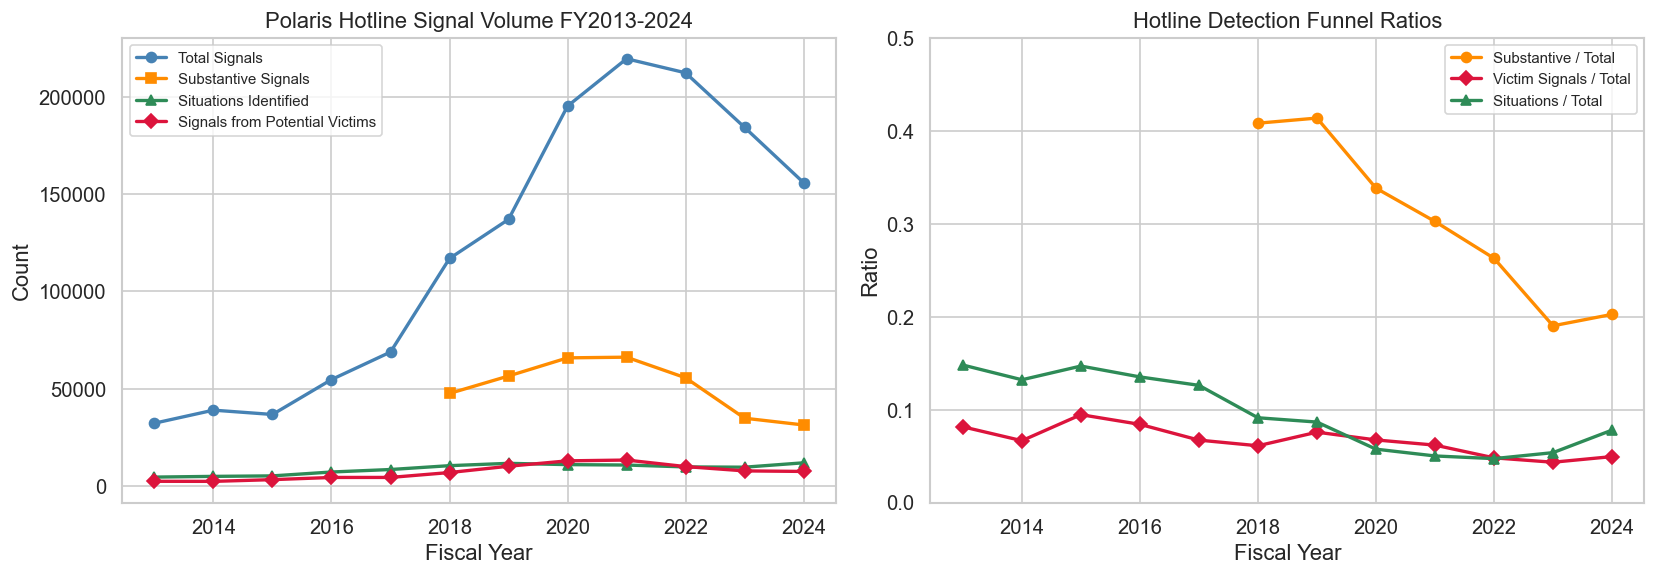

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total signals over time
ax = axes[0]
ax.plot(df01['fiscal_year'], df01['total_signals'], marker='o', linewidth=2, color='steelblue', label='Total Signals')
ax.plot(df01['fiscal_year'], df01['substantive_signals'], marker='s', linewidth=2, color='darkorange', label='Substantive Signals')
ax.plot(df01['fiscal_year'], df01['potential_situations_identified'], marker='^', linewidth=2, color='seagreen', label='Situations Identified')
ax.plot(df01['fiscal_year'], df01['signals_from_potential_victims'], marker='D', linewidth=2, color='crimson', label='Signals from Potential Victims')
ax.set_title('Polaris Hotline Signal Volume FY2013-2024')
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Count')
ax.legend(fontsize=9)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Funnel ratios
ax2 = axes[1]
df01_clean = df01.dropna(subset=['substantive_signals'])
if len(df01_clean) > 0:
    subst_ratio = df01_clean['substantive_signals'] / df01_clean['total_signals']
    ax2.plot(df01_clean['fiscal_year'], subst_ratio, marker='o', linewidth=2, color='darkorange', label='Substantive / Total')

victim_ratio    = df01['signals_from_potential_victims'] / df01['total_signals']
situation_ratio = df01['potential_situations_identified'] / df01['total_signals']
ax2.plot(df01['fiscal_year'], victim_ratio,    marker='D', linewidth=2, color='crimson',  label='Victim Signals / Total')
ax2.plot(df01['fiscal_year'], situation_ratio, marker='^', linewidth=2, color='seagreen', label='Situations / Total')
ax2.set_title('Hotline Detection Funnel Ratios')
ax2.set_xlabel('Fiscal Year')
ax2.set_ylabel('Ratio')
ax2.set_ylim(0, 0.5)
ax2.legend(fontsize=9)
ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

In [44]:
peak_idx  = df01['total_signals'].idxmax()
peak_year = df01.loc[peak_idx, 'fiscal_year']
peak_val  = df01.loc[peak_idx, 'total_signals']
last_val  = df01.loc[df01['fiscal_year'].idxmax(), 'total_signals']
print(f'Peak year: {peak_year}, volume: {peak_val:,}')
print(f'Last year volume: {last_val:,}')
print(f'Decline from peak: {(peak_val - last_val)/peak_val:.1%}')
print(f'Growth FY2013 to peak: {(peak_val - df01["total_signals"].iloc[0])/df01["total_signals"].iloc[0]:.1%}')

Peak year: 2021, volume: 219,380
Last year volume: 155,819
Decline from peak: 29.0%
Growth FY2013 to peak: 576.3%


**Explanation:**  
Total signals grew roughly 6x from FY2013 to the peak, then fell about 29% by FY2024. That kind of drop is hard to attribute to an actual decrease in trafficking activity. It more likely reflects platform changes and shifts in reporting infrastructure, including FOSTA-SESTA in 2018 and the post-COVID migration of activity online. What is notable is that the victim-signal ratio and situation ratio stayed relatively stable throughout this period, which suggests the detection efficiency of the hotline itself did not change much even as raw volume swung around. Also worth noting: `substantive_signals` is missing for several early years, which is informative on its own since it points to a methodology change at some point.

---
## 2. OVC Victims Served — FY 2023–2024 (`02`)

In [45]:
df02 = pd.read_csv(BASE + '02_ovc_victims_served_fy23_fy24.csv')
print(df02.shape)
df02

(8, 8)


,fiscal_year,quarter,sex_trafficking,labor_trafficking,eligible_family_members,undetermined,sex_and_labor,quarterly_total
0,2024,Q1,2429,614,564,368,296,4271
1,2024,Q2,2385,659,492,268,261,4065
2,2024,Q3,2262,571,486,224,223,3766
3,2024,Q4,1990,559,468,325,197,3539
4,2023,Q1,1823,532,500,109,182,3146
5,2023,Q2,1971,610,558,208,84,3431
6,2023,Q3,2000,463,414,128,190,3195
7,2023,Q4,1892,451,425,201,178,3147


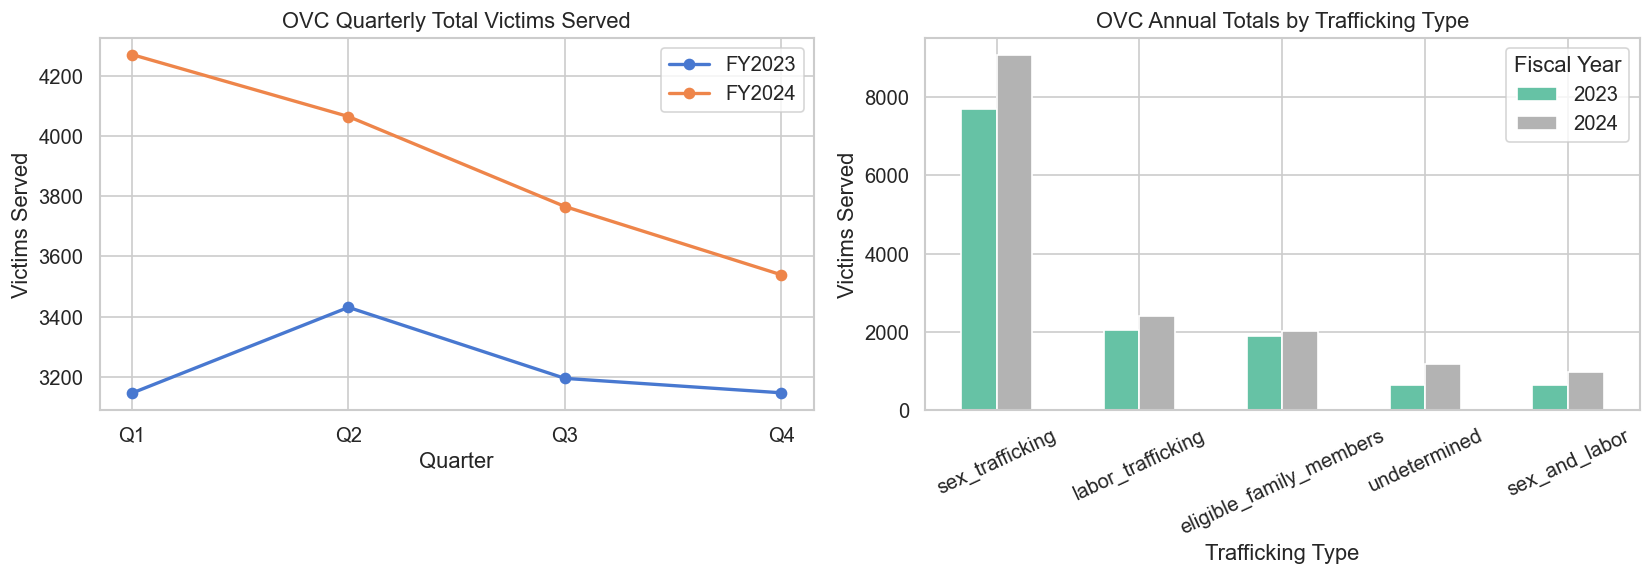

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for fy, grp in df02.groupby('fiscal_year'):
    axes[0].plot(grp['quarter'], grp['quarterly_total'], marker='o', linewidth=2, label=f'FY{fy}')
axes[0].set_title('OVC Quarterly Total Victims Served')
axes[0].set_xlabel('Quarter')
axes[0].set_ylabel('Victims Served')
axes[0].legend()

annual = df02.groupby('fiscal_year')[['sex_trafficking','labor_trafficking','eligible_family_members','undetermined','sex_and_labor']].sum()
annual.T.plot(kind='bar', ax=axes[1], colormap='Set2')
axes[1].set_title('OVC Annual Totals by Trafficking Type')
axes[1].set_xlabel('Trafficking Type')
axes[1].set_ylabel('Victims Served')
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend(title='Fiscal Year')

plt.tight_layout()
plt.show()

In [47]:
for col in ['sex_trafficking', 'labor_trafficking', 'quarterly_total']:
    fy23 = df02[df02['fiscal_year'] == 2023][col].sum()
    fy24 = df02[df02['fiscal_year'] == 2024][col].sum()
    print(f'{col}: FY23={fy23:,}  FY24={fy24:,}  delta={fy24-fy23:+,} ({(fy24-fy23)/fy23:+.1%})')

sex_trafficking: FY23=7,686  FY24=9,066  delta=+1,380 (+18.0%)
labor_trafficking: FY23=2,056  FY24=2,403  delta=+347 (+16.9%)
quarterly_total: FY23=12,919  FY24=15,641  delta=+2,722 (+21.1%)


**Explanation:**  
Sex trafficking caseloads grew from FY23 to FY24 while labor trafficking stayed roughly flat. This divergence likely reflects differences in service capacity expansion rather than a real shift in the underlying crime mix. Within each fiscal year, quarterly totals tend to decline from Q1 to Q4, which could be a sign of mid-year capacity saturation or reporting lag in grantee data. The main thing to keep in mind here is that these service counts represent a lower bound on the number of victims who actually needed services. They tell us about capacity, not prevalence.

---
## 3. CTDC Global by Year & Exploitation Type (`03`)

In [48]:
df03 = pd.read_csv(BASE + '03_ctdc_global_by_year_exploitation_type.csv')
print(df03.shape)
df03.head()

(18, 16)


,year,n_records,n_female,n_male,forced_labour_n,forced_labour_denom,sexual_exploit_n,sexual_exploit_denom,sex_and_labour_n,sex_and_labour_denom,forced_marriage_n,forced_marriage_denom,organ_removal_n,organ_removal_denom,slavery_practices_n,slavery_practices_denom
0,2002,1026,1026,0,0,919,867,919,0,919,0,845,0,919,0,0
1,2003,357,342,15,0,357,357,357,0,357,0,320,0,357,0,0
2,2004,223,223,0,0,223,160,223,0,223,0,223,0,223,0,0
3,2005,1455,1030,425,817,1431,492,1431,0,1431,0,1431,0,1431,0,0
4,2006,1423,1134,289,622,1181,318,1078,0,1078,0,1078,0,1078,0,0


In [49]:
for exploit in ['forced_labour', 'sexual_exploit', 'sex_and_labour', 'forced_marriage', 'organ_removal', 'slavery_practices']:
    n_col, d_col = f'{exploit}_n', f'{exploit}_denom'
    if n_col in df03.columns and d_col in df03.columns:
        df03[f'{exploit}_prop'] = df03[n_col] / df03[d_col].replace(0, np.nan)

df03[['year','n_records','forced_labour_prop','sexual_exploit_prop','forced_marriage_prop']].tail(10)

,year,n_records,forced_labour_prop,sexual_exploit_prop,forced_marriage_prop
8,2010,943,0.959410,0.138182,NaN
9,2011,1340,1.000000,0.000000,NaN
10,2012,1367,1.000000,0.000000,0.000000
11,2013,1832,1.000000,0.000000,0.000000
12,2014,3000,0.910309,0.000000,0.000000
13,2015,4276,0.532258,0.462757,0.000000
14,2016,16399,0.493314,0.837844,0.000000
15,2017,6508,0.114446,0.914070,0.265060
16,2018,5818,0.028223,0.972183,0.013848
17,2019,28,0.000000,1.000000,0.000000


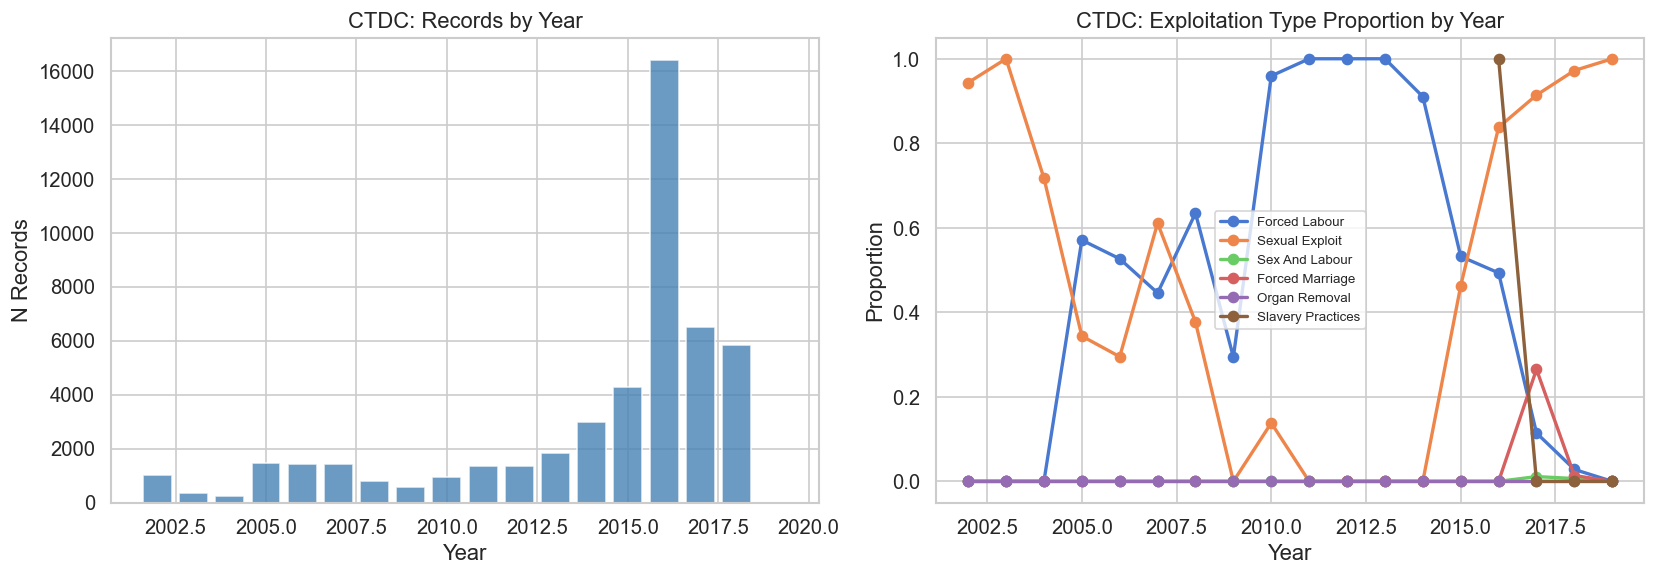

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(df03['year'], df03['n_records'], color='steelblue', alpha=0.8)
axes[0].set_title('CTDC: Records by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('N Records')

prop_cols = [c for c in df03.columns if c.endswith('_prop')]
labels    = [c.replace('_prop','').replace('_',' ').title() for c in prop_cols]
for col, lbl in zip(prop_cols, labels):
    subset = df03.dropna(subset=[col])
    axes[1].plot(subset['year'], subset[col], marker='o', linewidth=2, label=lbl)
axes[1].set_title('CTDC: Exploitation Type Proportion by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Proportion')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

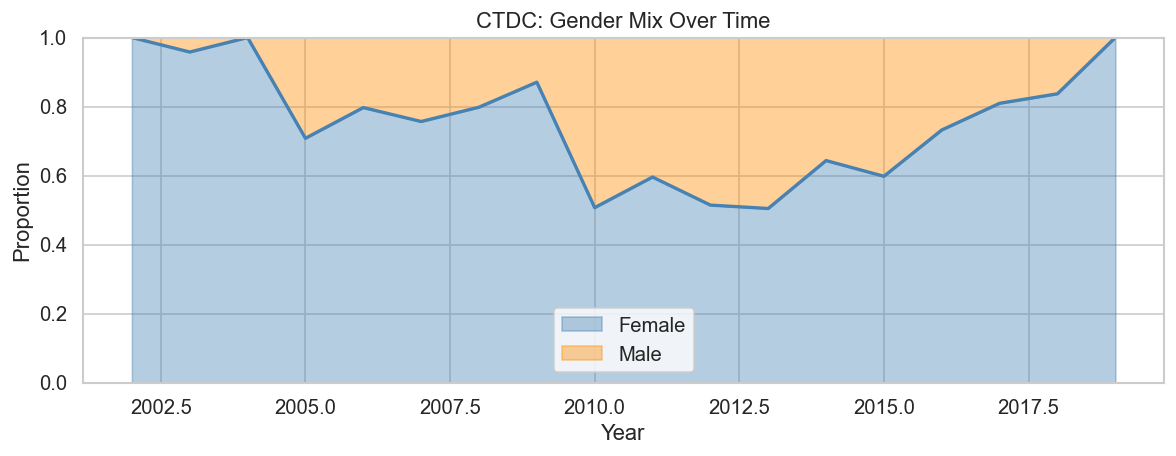

In [51]:
df03['pct_female'] = df03['n_female'] / df03['n_records']

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(df03['year'], df03['pct_female'], alpha=0.4, color='steelblue', label='Female')
ax.fill_between(df03['year'], df03['pct_female'], 1, alpha=0.4, color='darkorange', label='Male')
ax.plot(df03['year'], df03['pct_female'], color='steelblue', linewidth=2)
ax.set_ylim(0, 1)
ax.set_title('CTDC: Gender Mix Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Proportion')
ax.legend()
plt.tight_layout()
plt.show()

**Explanation:**  
Record counts vary a lot across years, but this reflects how many organizations were contributing data to CTDC at the time rather than actual changes in trafficking volume. Sexual exploitation consistently makes up the largest share of exploitation types across all years. The female proportion is high overall but shifts noticeably in some years, which is likely a datasource composition artifact. When a new datasource with a different gender mix gets added, the aggregate proportion moves even if nothing changed in reality. Male victims are probably systematically under-identified, so these gender ratios should be read cautiously.

---
## 4. Means of Control by Exploitation Type (`04`)

In [52]:
df04 = pd.read_csv(BASE + '04_ctdc_means_of_control_by_exploitation.csv')
print(df04.shape)
df04.head()

(32, 6)


,exploitation_type,means_of_control,n_positive,n_observed,raw_prevalence,beta_posterior_mean
0,forced_labour,debt_bondage,641,715,0.896503,0.895397
1,forced_labour,takes_earnings,1726,1796,0.961024,0.960512
2,forced_labour,restricts_financial_access,0,78,0.000000,0.012500
3,forced_labour,threats,1384,1428,0.969188,0.968531
4,forced_labour,psychological_abuse,1717,1777,0.966235,0.965711


In [53]:
print(df04['exploitation_type'].unique())
print(df04['means_of_control'].unique())

['forced_labour' 'sexual_exploit']
['debt_bondage' 'takes_earnings' 'restricts_financial_access' 'threats'
 'psychological_abuse' 'physical_abuse' 'sexual_abuse' 'false_promises'
 'psychoactive_substances' 'restricts_movement' 'restricts_medical_care'
 'excessive_working_hours' 'uses_children' 'threat_law_enforcement'
 'withholds_necessities' 'withholds_documents']


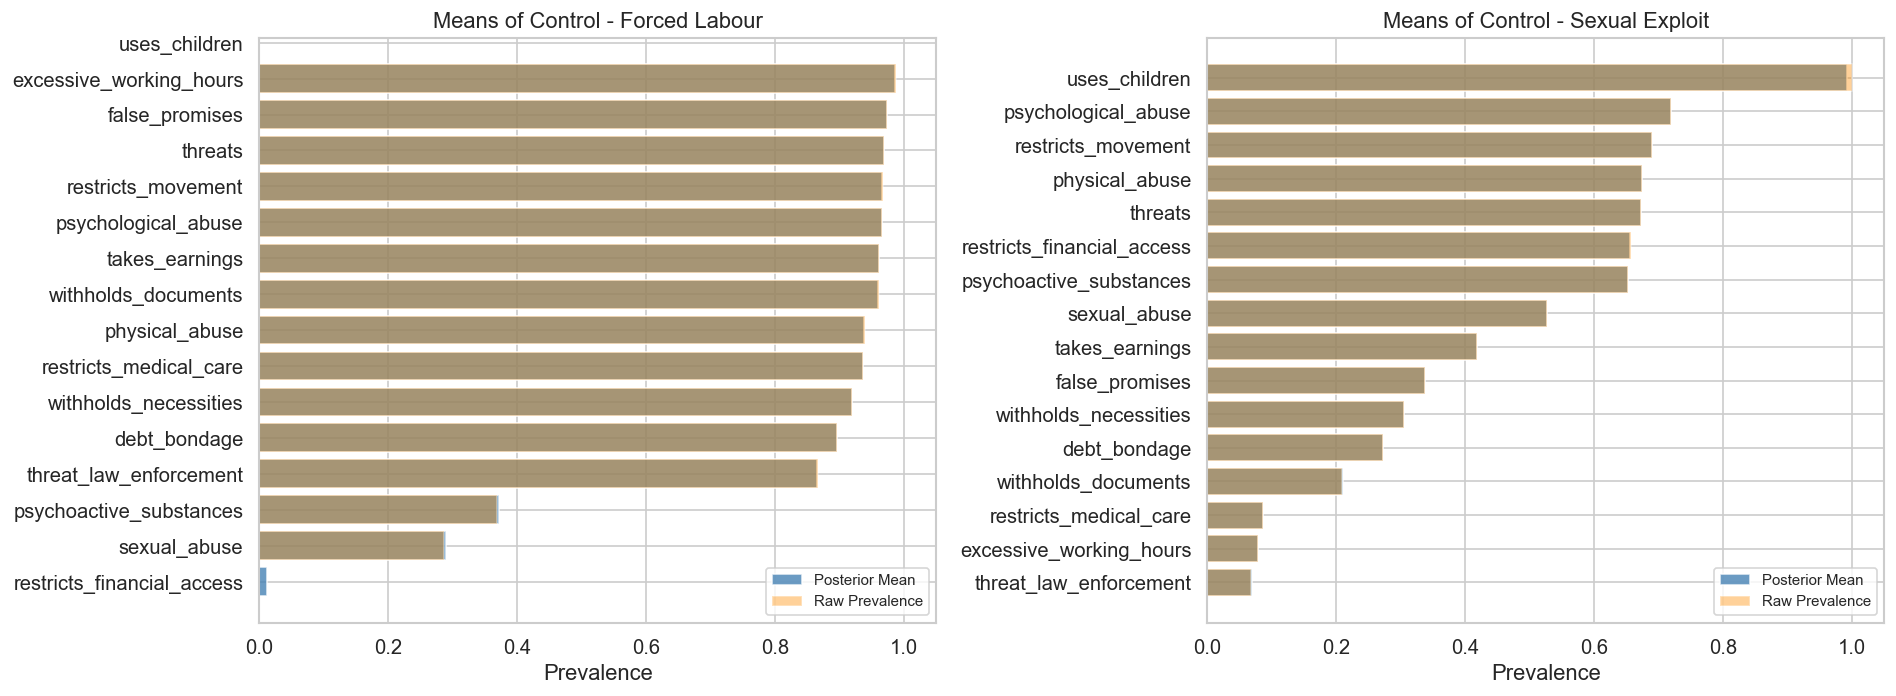

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, exploit in zip(axes, df04['exploitation_type'].unique()[:2]):
    sub = df04[df04['exploitation_type'] == exploit].sort_values('beta_posterior_mean', ascending=True)
    ax.barh(sub['means_of_control'], sub['beta_posterior_mean'], color='steelblue', alpha=0.8, label='Posterior Mean')
    ax.barh(sub['means_of_control'], sub['raw_prevalence'],      color='darkorange', alpha=0.4, label='Raw Prevalence')
    ax.set_xlim(0, 1.05)
    ax.set_title(f'Means of Control - {exploit.replace("_"," ").title()}')
    ax.set_xlabel('Prevalence')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

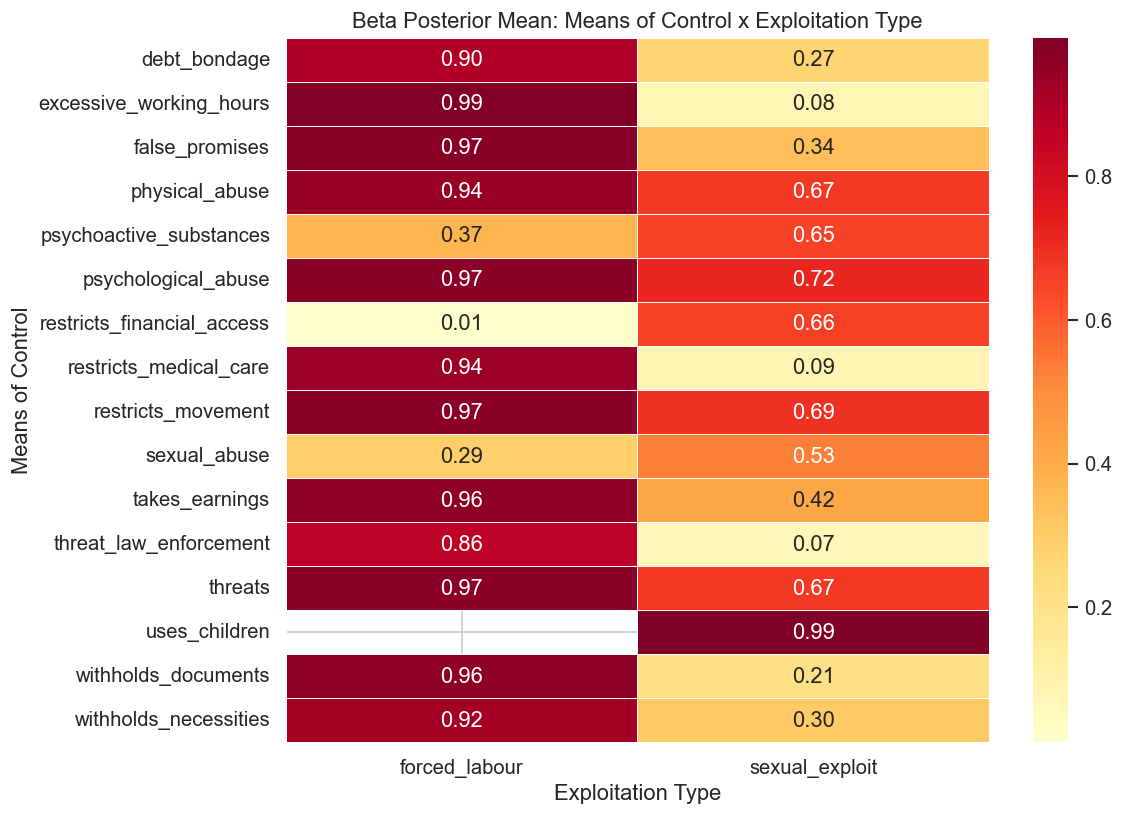

In [55]:
# Heatmap: exploitation type x means of control
pivot = df04.pivot(index='means_of_control', columns='exploitation_type', values='beta_posterior_mean')

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Beta Posterior Mean: Means of Control x Exploitation Type')
ax.set_xlabel('Exploitation Type')
ax.set_ylabel('Means of Control')
plt.tight_layout()
plt.show()

In [56]:
# Bayesian shrinkage magnitude
df04['shrinkage'] = df04['beta_posterior_mean'] - df04['raw_prevalence']
print('Largest shrinkage (sparse cells, prior has more influence):')
print(df04.nlargest(5, 'shrinkage')[['exploitation_type','means_of_control','n_observed','raw_prevalence','beta_posterior_mean','shrinkage']])
print('\nSmallest shrinkage (high-n cells, minimal regularization):')
print(df04.nsmallest(5, 'shrinkage')[['exploitation_type','means_of_control','n_observed','raw_prevalence','beta_posterior_mean','shrinkage']])

Largest shrinkage (sparse cells, prior has more influence):
   exploitation_type            means_of_control  n_observed  raw_prevalence  \
2      forced_labour  restricts_financial_access          78        0.000000   
6      forced_labour                sexual_abuse         105        0.285714   
8      forced_labour     psychoactive_substances         122        0.368852   
29    sexual_exploit      threat_law_enforcement        1186        0.068297   
27    sexual_exploit     excessive_working_hours        1171        0.077711   

    beta_posterior_mean  shrinkage  
2              0.012500   0.012500  
6              0.289720   0.004005  
8              0.370968   0.002115  
29             0.069024   0.000727  
27             0.078431   0.000720  

Smallest shrinkage (high-n cells, minimal regularization):
   exploitation_type            means_of_control  n_observed  raw_prevalence  \
28    sexual_exploit               uses_children         119        1.000000   
18    sexual_expl

**Explanation:**  
In forced labour cases, `takes_earnings` and `debt_bondage` show up in nearly every case with posterior means above 0.9. In sexual exploitation, `restricts_movement` is the most prevalent control mechanism. The shrinkage analysis shows that cells with small `n_observed` get pulled noticeably toward the prior mean under the Beta(1,1) assumption, while high-n cells are barely affected. This makes sense statistically, but it also means that for exploitation type and country combinations with limited data, the posterior estimates are driven more by the prior than by the actual observations. These posterior means serve as a natural starting point for the Hierarchical Beta-Binomial model in Contribution 2.

---
## 5. Top 30 Countries of Exploitation (`05`)

In [57]:
df05 = pd.read_csv(BASE + '05_ctdc_top30_countries_of_exploitation.csv')
print(df05.shape)
df05.head()

(30, 6)


,CountryOfExploitation,n_records,n_female,n_male,n_forced_labour,n_sexual_exploit
0,US,12512,12168,344,197,11855
1,UA,5399,2941,2458,54,55
2,MD,4504,3615,889,0,77
3,RU,2738,819,1919,2282,478
4,PH,1988,1369,619,742,120


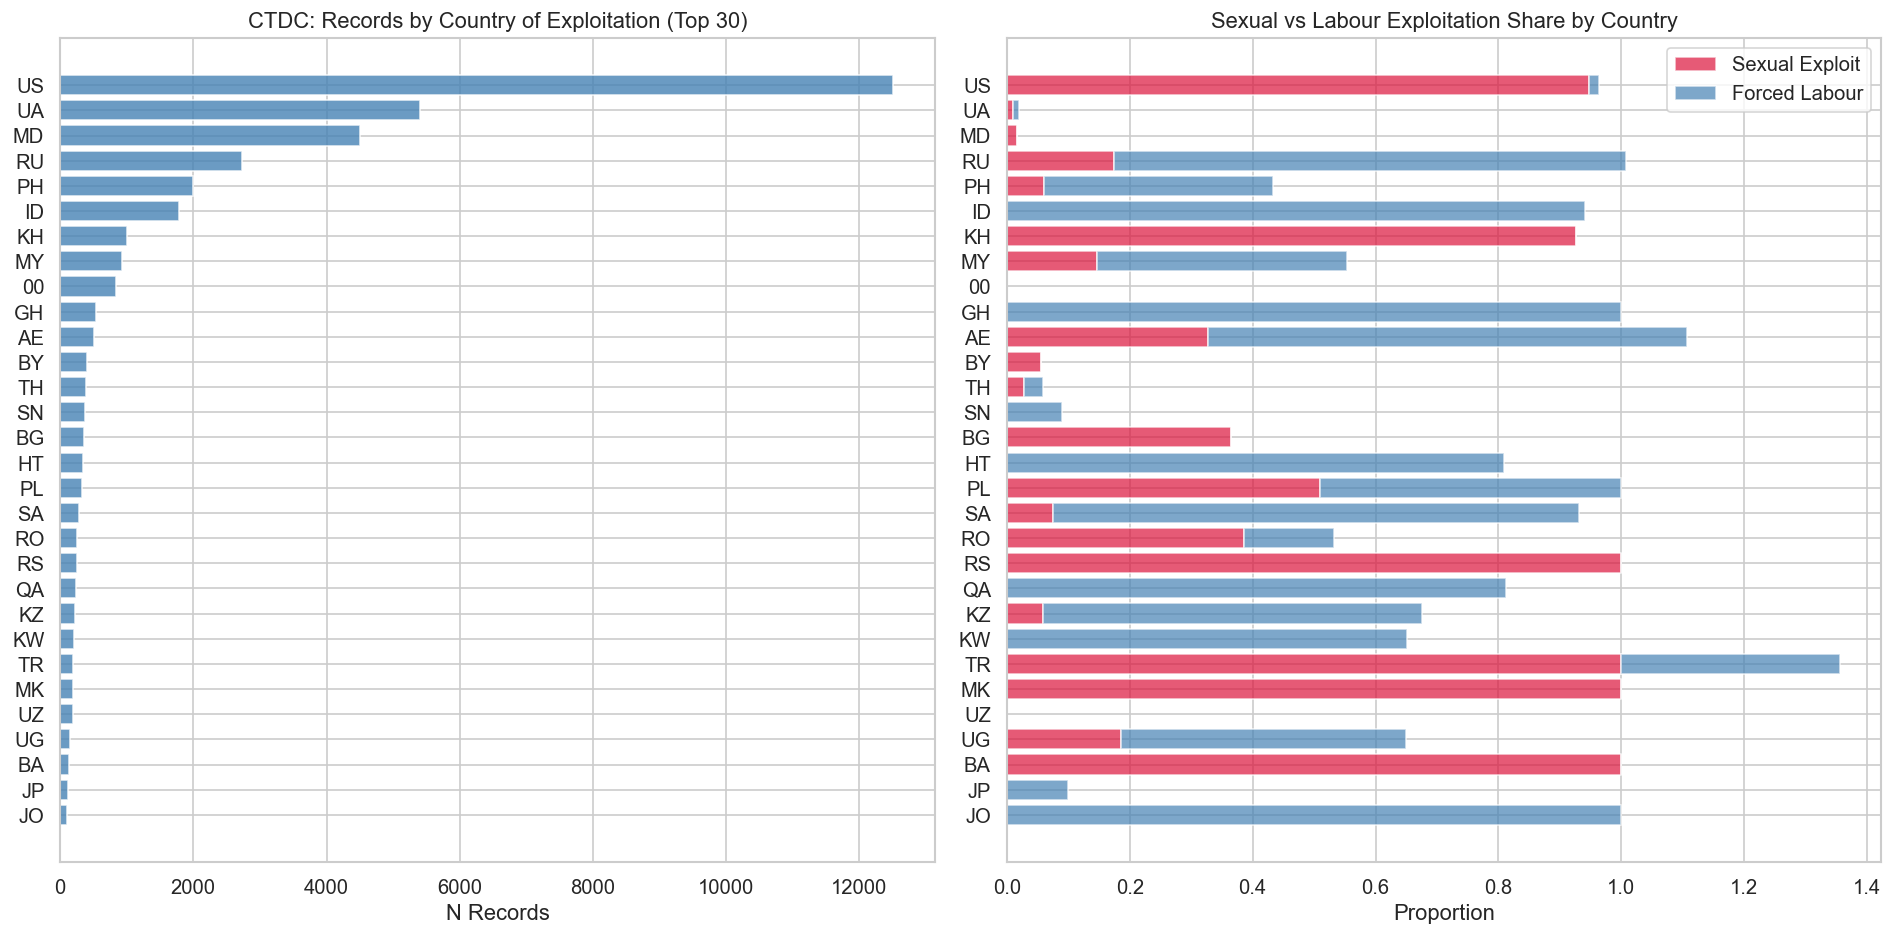

In [58]:
df05['pct_labour'] = df05['n_forced_labour'] / df05['n_records']
df05['pct_sexual'] = df05['n_sexual_exploit'] / df05['n_records']
df05['pct_female'] = df05['n_female'] / df05['n_records']

df05_sorted = df05.sort_values('n_records', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(df05_sorted['CountryOfExploitation'], df05_sorted['n_records'], color='steelblue', alpha=0.8)
axes[0].set_title('CTDC: Records by Country of Exploitation (Top 30)')
axes[0].set_xlabel('N Records')
axes[0].invert_yaxis()

axes[1].barh(df05_sorted['CountryOfExploitation'], df05_sorted['pct_sexual'],
             color='crimson', alpha=0.7, label='Sexual Exploit')
axes[1].barh(df05_sorted['CountryOfExploitation'], df05_sorted['pct_labour'],
             left=df05_sorted['pct_sexual'], color='steelblue', alpha=0.7, label='Forced Labour')
axes[1].set_title('Sexual vs Labour Exploitation Share by Country')
axes[1].set_xlabel('Proportion')
axes[1].legend()
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

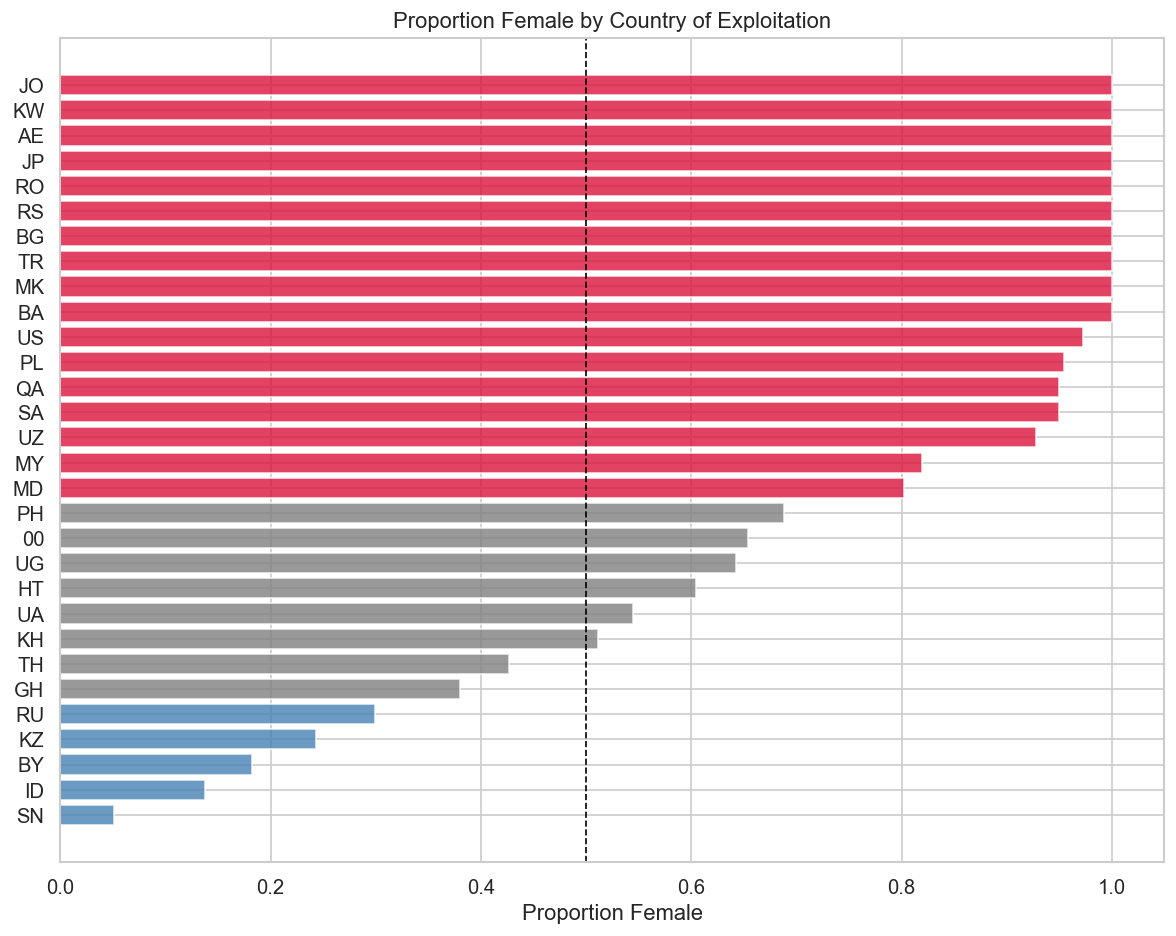

In [59]:
fig, ax = plt.subplots(figsize=(10, 8))
df05_f = df05.sort_values('pct_female', ascending=True)
colors = ['crimson' if p > 0.7 else 'steelblue' if p < 0.3 else 'gray' for p in df05_f['pct_female']]
ax.barh(df05_f['CountryOfExploitation'], df05_f['pct_female'], color=colors, alpha=0.8)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1)
ax.set_title('Proportion Female by Country of Exploitation')
ax.set_xlabel('Proportion Female')
plt.tight_layout()
plt.show()

**Explanation:**  
The US has by far the most records in this dataset, but that is largely because CTDC includes Polaris as a contributing datasource, and Polaris is a US-based organization. This does not mean the US has the highest actual trafficking prevalence. Countries like UA and RU show high forced labour shares and correspondingly higher male proportions, which is consistent with what we know about regional trafficking patterns. The broader point is that record counts here should not be interpreted as prevalence estimates. They reflect data collection capacity and organizational reach as much as anything else.

---
## 6. Age-Gender Exploitation Crosstab (`06`)

In [60]:
df06 = pd.read_csv(BASE + '06_ctdc_age_gender_exploitation_crosstab.csv')
print(df06.shape)
df06

(18, 7)


,ageBroad,gender,n,n_forced_labour,n_sexual_exploit,n_forced_labour_obs,n_sexual_exploit_obs
0,0--8,Female,841,101,122,223,211
1,0--8,Male,715,121,36,157,157
2,18--20,Female,4227,256,2906,3237,3238
3,18--20,Male,221,90,30,120,120
4,21--23,Female,3734,211,2325,2660,2635
5,21--23,Male,479,264,25,289,289
6,24--26,Female,2816,174,1551,1854,1854
7,24--26,Male,648,347,17,364,364
8,27--29,Female,1869,227,891,1144,1118
9,27--29,Male,772,416,0,416,403


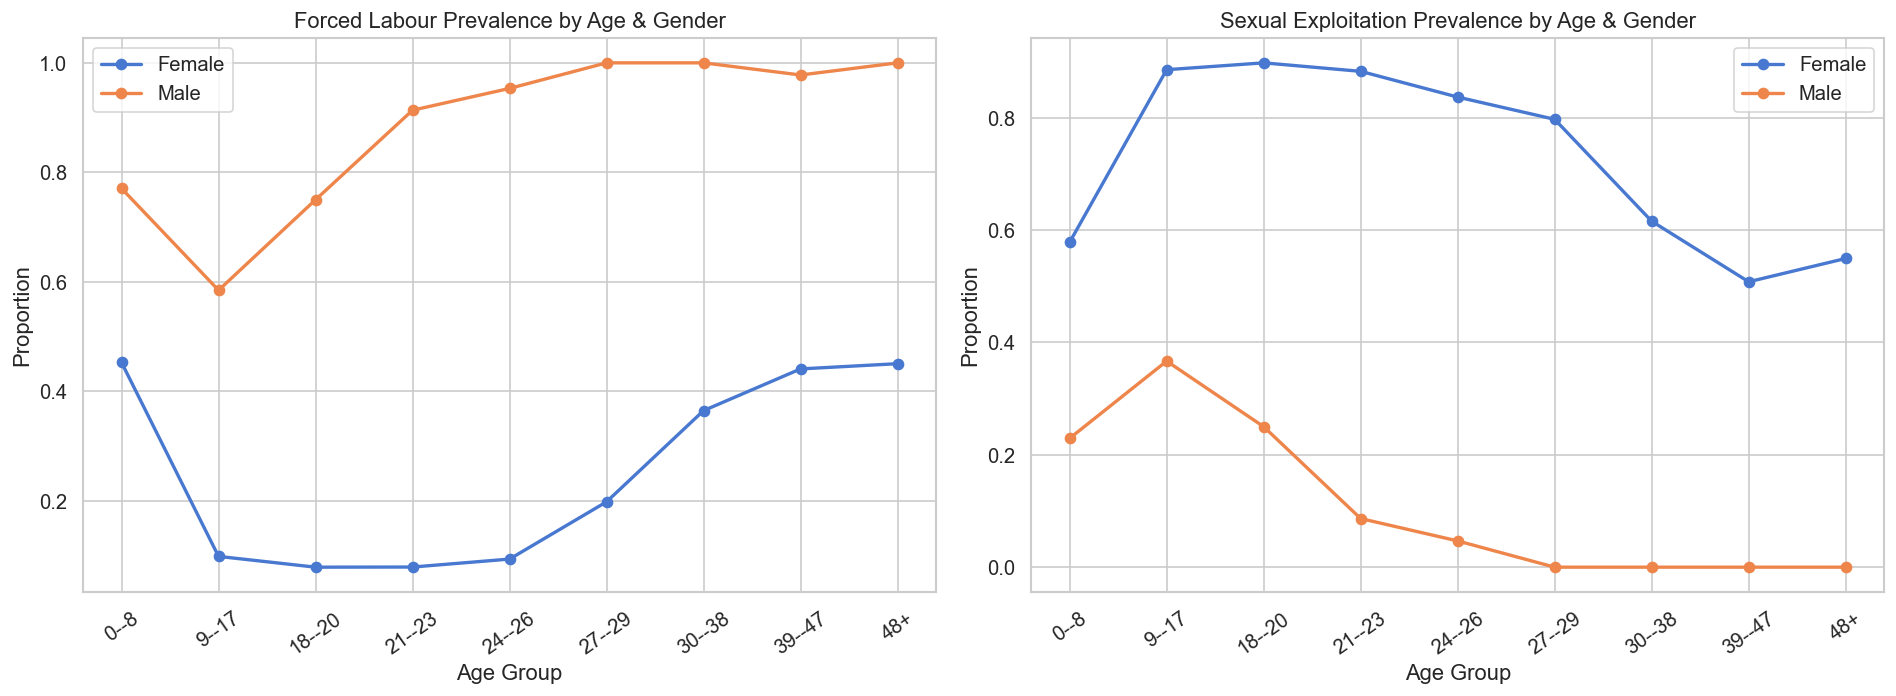

In [61]:
df06['pct_forced_labour']  = df06['n_forced_labour']  / df06['n_forced_labour_obs'].replace(0, np.nan)
df06['pct_sexual_exploit'] = df06['n_sexual_exploit'] / df06['n_sexual_exploit_obs'].replace(0, np.nan)

age_order = ['0--8','9--17','18--20','21--23','24--26','27--29','30--38','39--47','48+','Unknown']
df06['ageBroad'] = pd.Categorical(df06['ageBroad'], categories=age_order, ordered=True)
df06 = df06.sort_values('ageBroad')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (pct_col, title) in zip(axes, [
    ('pct_forced_labour',  'Forced Labour Prevalence by Age & Gender'),
    ('pct_sexual_exploit', 'Sexual Exploitation Prevalence by Age & Gender'),
]):
    for gender, grp in df06.groupby('gender'):
        ax.plot(grp['ageBroad'].astype(str), grp[pct_col], marker='o', linewidth=2, label=gender)
    ax.set_title(title)
    ax.set_xlabel('Age Group')
    ax.set_ylabel('Proportion')
    ax.tick_params(axis='x', rotation=35)
    ax.legend()

plt.tight_layout()
plt.show()

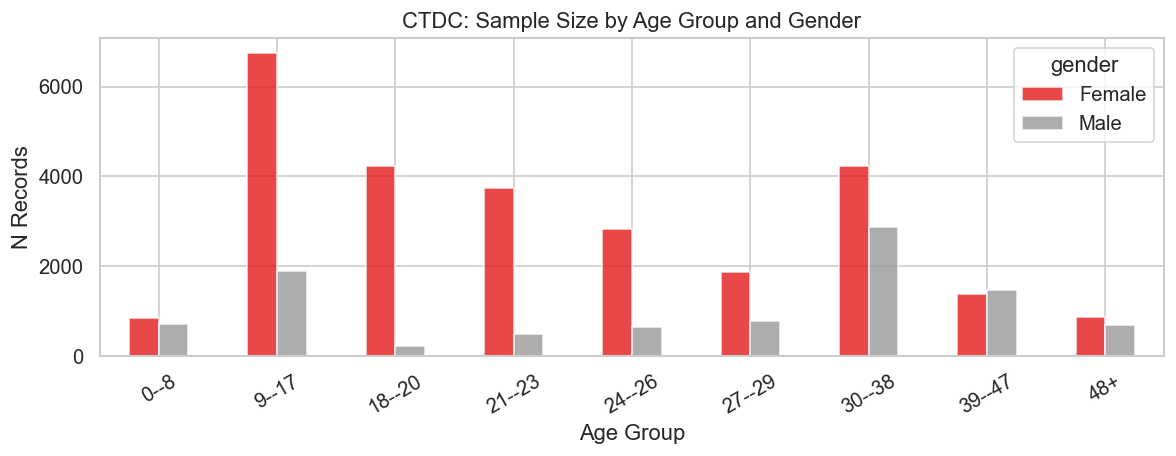

In [62]:
# Sample size by age and gender -- understand where inference is reliable
pivot_n = df06.pivot(index='ageBroad', columns='gender', values='n').astype(float)

fig, ax = plt.subplots(figsize=(10, 4))
pivot_n.plot(kind='bar', ax=ax, colormap='Set1', alpha=0.8)
ax.set_title('CTDC: Sample Size by Age Group and Gender')
ax.set_xlabel('Age Group')
ax.set_ylabel('N Records')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

**Explanation:**  
Sexual exploitation prevalence peaks sharply in the 18 to 26 age range for females, while forced labour is distributed more evenly across age groups. The very young (0 to 8) and older age groups have small sample sizes, which means posterior estimates for those cells will be driven heavily by the prior rather than the data. For male victims, the sexual exploitation prevalence figures are likely understated. Identification of male victims in this context tends to be systematically lower due to how screening and referral processes are designed, so the male numbers here should be treated as a lower bound.

---
## 7. Polaris State Hotline Statistics 2024 (`07`)

In [63]:
df07 = pd.read_csv(BASE + '07_polaris_state_hotline_statistics_2024.csv')
print(df07.shape)
df07.head()

(56, 11)


,jurisdiction,jurisdiction_type,slug,all_time_signals,all_time_cases,all_time_victims,signals_2024,signals_from_victims_2024,cases_2024,victims_2024,source_url
0,Alabama,state,alabama,3224,927,1969,231.0,83.0,105.0,141.0,https://humantraffickinghotline.org/en/statist...
1,Alaska,state,alaska,694,181,353,46.0,6.0,22.0,44.0,https://humantraffickinghotline.org/en/statist...
2,American Samoa,territory_or_dc,american-samoa,10,4,8,NaN,NaN,NaN,NaN,https://humantraffickinghotline.org/en/statist...
3,Arizona,state,arizona,6525,2306,5186,550.0,175.0,300.0,671.0,https://humantraffickinghotline.org/en/statist...
4,Arkansas,state,arkansas,2413,770,1929,170.0,56.0,80.0,153.0,https://humantraffickinghotline.org/en/statist...


In [64]:
print('Missing values per column:')
print(df07.isnull().sum())

states = df07[df07['jurisdiction_type'] == 'state'].copy()
print(f'\nStates: {len(states)}, Other jurisdictions: {len(df07) - len(states)}')

Missing values per column:
jurisdiction                 0
jurisdiction_type            0
slug                         0
all_time_signals             0
all_time_cases               0
all_time_victims             0
signals_2024                 4
signals_from_victims_2024    3
cases_2024                   4
victims_2024                 4
source_url                   0
dtype: int64

States: 50, Other jurisdictions: 6


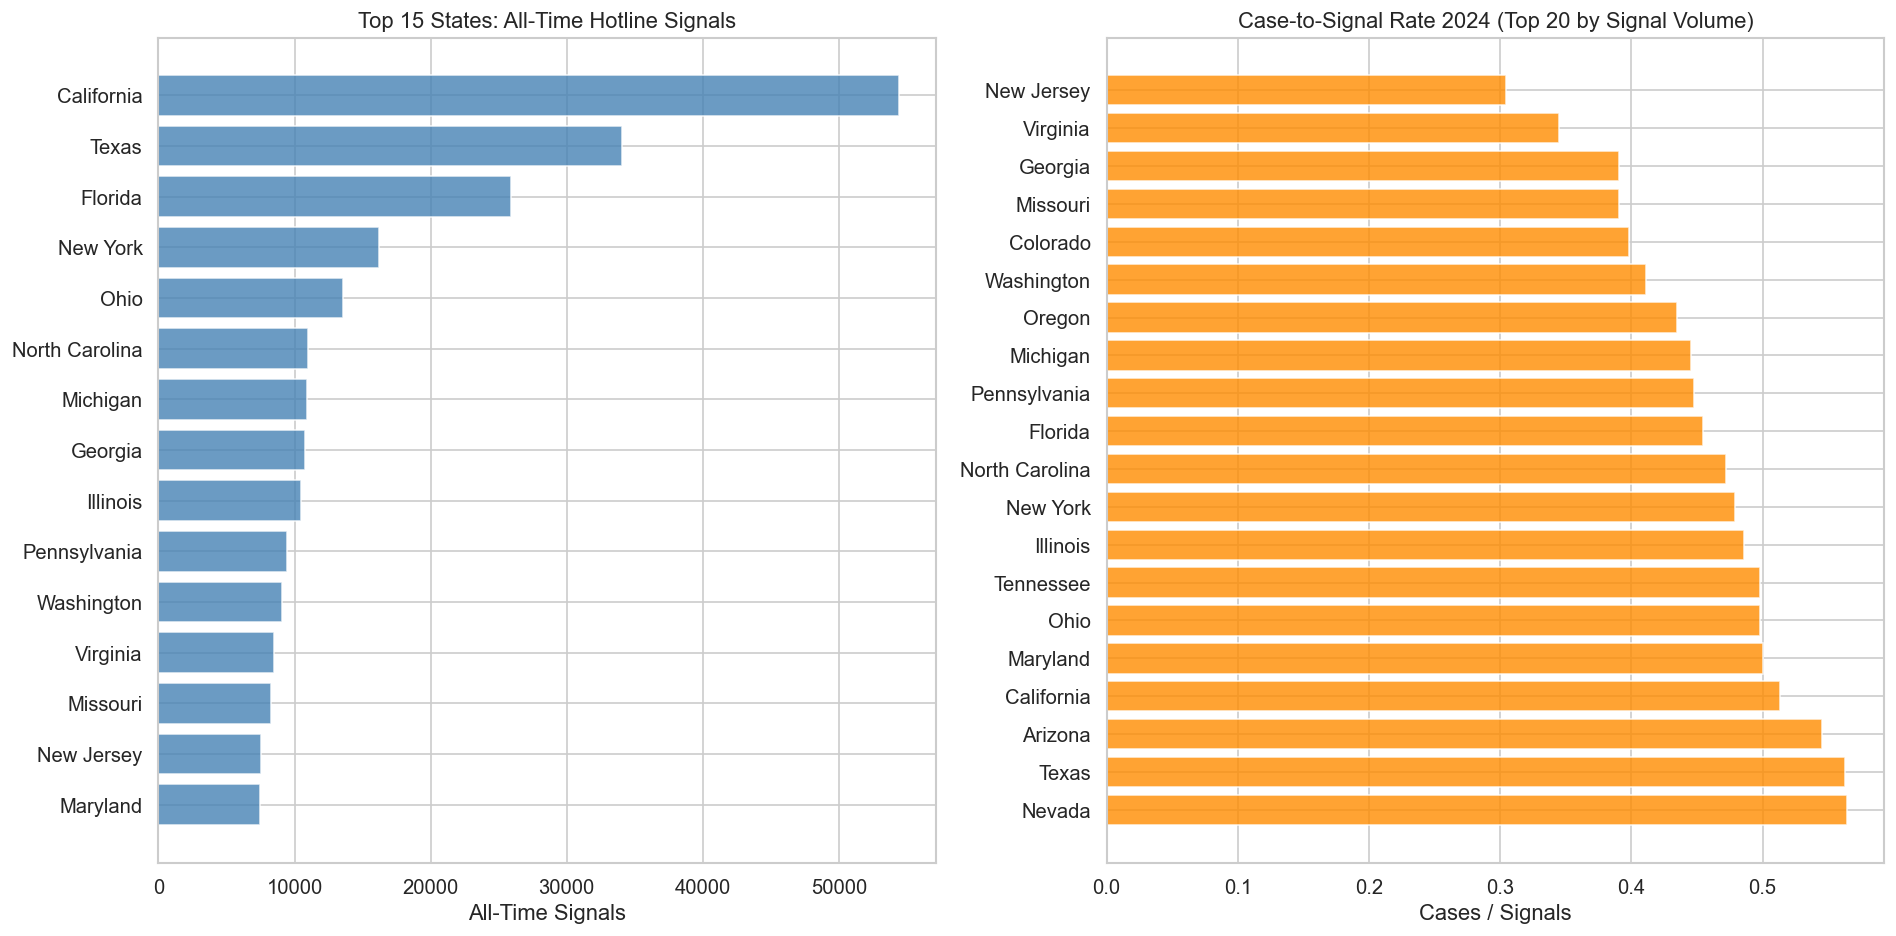

In [65]:
states['victim_signal_rate']  = states['signals_from_victims_2024'] / states['signals_2024']
states['case_to_signal_rate'] = states['cases_2024'] / states['signals_2024']

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top15 = states.nlargest(15, 'all_time_signals')
axes[0].barh(top15['jurisdiction'], top15['all_time_signals'], color='steelblue', alpha=0.8)
axes[0].set_title('Top 15 States: All-Time Hotline Signals')
axes[0].set_xlabel('All-Time Signals')
axes[0].invert_yaxis()

top20   = states.dropna(subset=['case_to_signal_rate']).nlargest(20, 'signals_2024')
top20_s = top20.sort_values('case_to_signal_rate', ascending=True)
axes[1].barh(top20_s['jurisdiction'], top20_s['case_to_signal_rate'], color='darkorange', alpha=0.8)
axes[1].set_title('Case-to-Signal Rate 2024 (Top 20 by Signal Volume)')
axes[1].set_xlabel('Cases / Signals')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

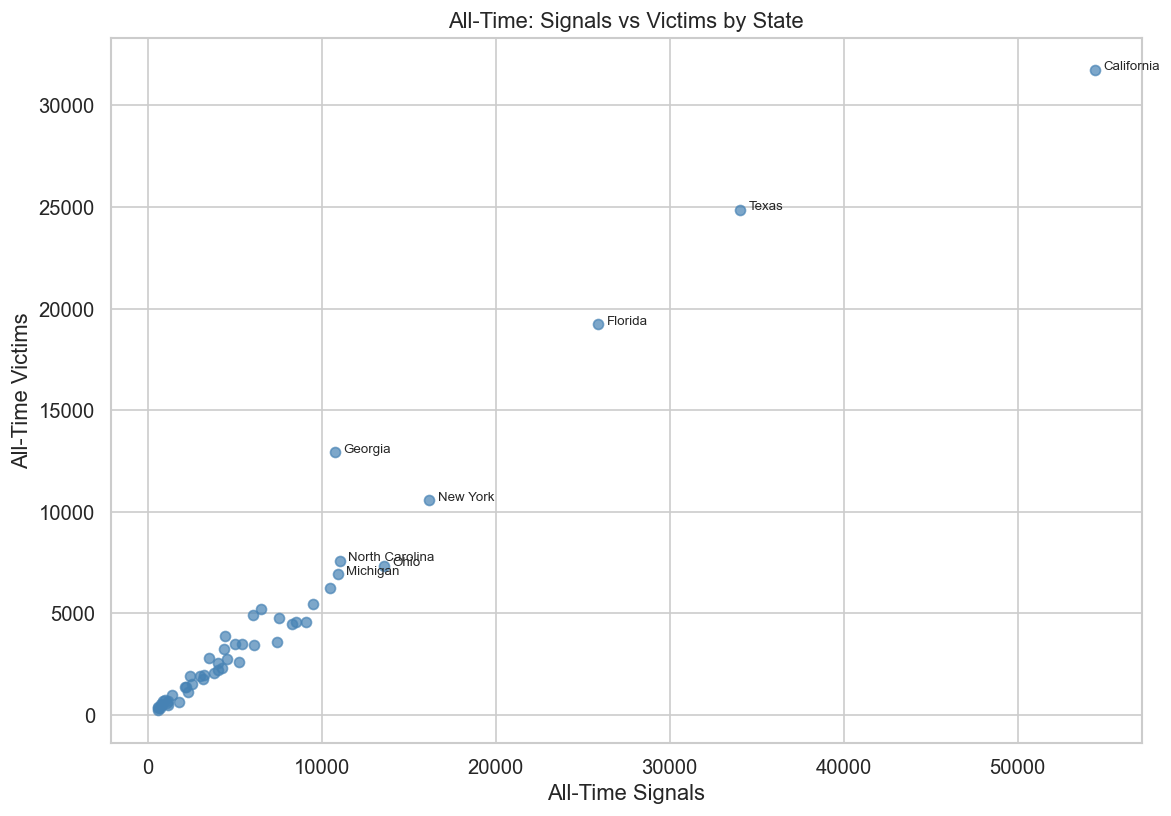

In [66]:
# Detection efficiency: all-time signals vs victims
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(states['all_time_signals'], states['all_time_victims'], alpha=0.7, color='steelblue')
for _, row in states.nlargest(8, 'all_time_signals').iterrows():
    ax.annotate(row['jurisdiction'], (row['all_time_signals'], row['all_time_victims']),
                fontsize=8, ha='left', xytext=(5, 0), textcoords='offset points')
ax.set_title('All-Time: Signals vs Victims by State')
ax.set_xlabel('All-Time Signals')
ax.set_ylabel('All-Time Victims')
plt.tight_layout()
plt.show()

**Explanation:**  
CA, TX, and FL account for a disproportionate share of total signal volume, though this is partly explained by population size and the concentration of enforcement infrastructure in those states rather than trafficking activity alone. More interesting is the case-to-signal rate, which varies substantially across states even among the highest-volume ones. Some states convert a much higher fraction of signals into formal cases than others. This kind of cross-state heterogeneity is exactly what motivates a hierarchical partial pooling approach in Contribution 1 rather than treating all states as equivalent. The territories with missing 2024 data should probably be modeled as a separate stratum.

---
## 8. BJS Federal Case Metrics — FY 2013–2023 (`08`)

In [67]:
df08 = pd.read_csv(BASE + '08_bjs_federal_human_trafficking_case_metrics_fy2013_2023.csv')
print(df08.shape)
df08[['fiscal_year','suspects_referred_to_us_attorneys','suspects_prosecuted_in_us_district_court','defendants_convicted']]

(11, 7)


,fiscal_year,suspects_referred_to_us_attorneys,suspects_prosecuted_in_us_district_court,defendants_convicted
0,2013,1893,1030,616
1,2014,1619,1051,725
2,2015,1923,1049,769
3,2016,1974,1093,771
4,2017,1926,1163,790
5,2018,1920,1107,777
6,2019,2091,1235,837
7,2020,2198,1343,658
8,2021,2027,1672,809
9,2022,1912,1656,1118


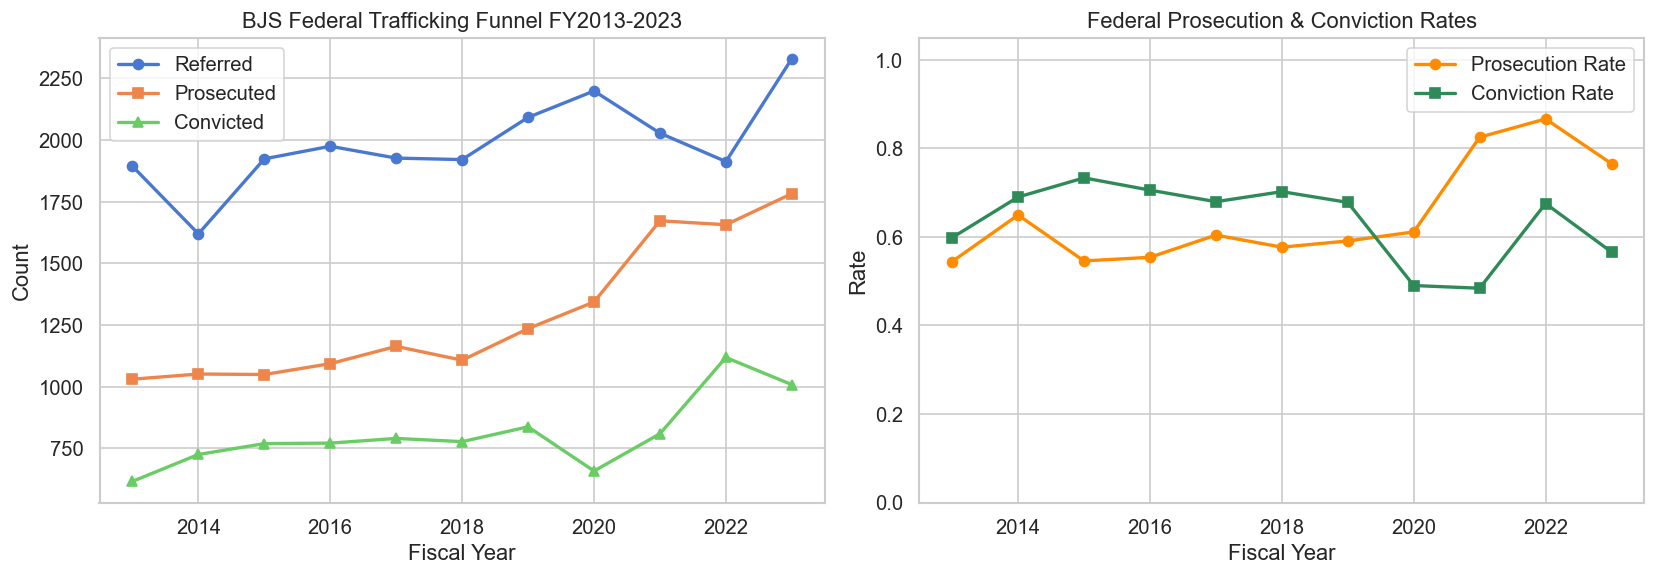

In [68]:
df08['prosecution_rate'] = df08['suspects_prosecuted_in_us_district_court'] / df08['suspects_referred_to_us_attorneys']
df08['conviction_rate']  = df08['defendants_convicted'] / df08['suspects_prosecuted_in_us_district_court']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df08['fiscal_year'], df08['suspects_referred_to_us_attorneys'],        marker='o', linewidth=2, label='Referred')
axes[0].plot(df08['fiscal_year'], df08['suspects_prosecuted_in_us_district_court'], marker='s', linewidth=2, label='Prosecuted')
axes[0].plot(df08['fiscal_year'], df08['defendants_convicted'],                      marker='^', linewidth=2, label='Convicted')
axes[0].set_title('BJS Federal Trafficking Funnel FY2013-2023')
axes[0].set_xlabel('Fiscal Year')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

axes[1].plot(df08['fiscal_year'], df08['prosecution_rate'], marker='o', linewidth=2, color='darkorange', label='Prosecution Rate')
axes[1].plot(df08['fiscal_year'], df08['conviction_rate'],  marker='s', linewidth=2, color='seagreen',   label='Conviction Rate')
axes[1].set_title('Federal Prosecution & Conviction Rates')
axes[1].set_xlabel('Fiscal Year')
axes[1].set_ylabel('Rate')
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

In [69]:
print('Overall funnel (FY2013-2023 totals):')
referred   = df08['suspects_referred_to_us_attorneys'].sum()
prosecuted = df08['suspects_prosecuted_in_us_district_court'].sum()
convicted  = df08['defendants_convicted'].sum()
print(f'  Referred:   {referred:,}')
print(f'  Prosecuted: {prosecuted:,}  ({prosecuted/referred:.1%} of referred)')
print(f'  Convicted:  {convicted:,}  ({convicted/prosecuted:.1%} of prosecuted)')
print(f'  End-to-end: {convicted/referred:.1%} referred to convicted')

Overall funnel (FY2013-2023 totals):
  Referred:   21,812
  Prosecuted: 14,181  (65.0% of referred)
  Convicted:  8,878  (62.6% of prosecuted)
  End-to-end: 40.7% referred to convicted


**Explanation:**  
Referral counts fluctuate year to year without a clear trend, but prosecution numbers are more stable, which points to a resource-constrained ceiling on what US Attorneys can actually process. The prosecution rate hovers around 50 to 60 percent, meaning a meaningful share of referred suspects never get prosecuted, likely due to evidentiary or prioritization decisions. Once a case does go to prosecution, the conviction rate is high, around 70 percent. The important framing here is that federal cases represent only a tiny slice of the estimated total trafficking population. This makes the BJS data useful as a third capture layer in a capture-recapture model precisely because it captures a very different and small subset of the overall population.

---
## 9. CTDC Global Dataset — Full Individual Records (~48,800 rows)

In [70]:
df_global = pd.read_csv(BASE + 'The Global Dataset 14 Apr 2020.csv')
# The first column name embeds the terms-of-use URL; rename it to something clean
df_global.rename(columns={df_global.columns[0]: 'record_id'}, inplace=True)
print(f'Shape: {df_global.shape}')
print('Columns:', list(df_global.columns[:10]))
df_global.head(2)

Shape: (48801, 64)
Columns: ['record_id', 'yearOfRegistration', 'Datasource', 'gender', 'ageBroad', 'majorityStatus', 'majorityStatusAtExploit', 'majorityEntry', 'citizenship', 'meansOfControlDebtBondage']


,record_id,yearOfRegistration,Datasource,gender,ageBroad,majorityStatus,majorityStatusAtExploit,majorityEntry,citizenship,meansOfControlDebtBondage,...,typeOfSexPrivateSexualServices,typeOfSexConcatenated,isAbduction,RecruiterRelationship,CountryOfExploitation,recruiterRelationIntimatePartner,recruiterRelationFriend,recruiterRelationFamily,recruiterRelationOther,recruiterRelationUnknown
0,NaN,2002,Case Management,Female,18--20,Adult,-99,-99,CO,-99,...,-99,-99,-99,-99,-99,0,0,0,0,1
1,NaN,2002,Case Management,Female,18--20,Adult,-99,-99,CO,-99,...,-99,-99,-99,-99,-99,0,0,0,0,1


In [71]:
# Replace sentinel value -99 with NaN
df_global.replace(-99, np.nan, inplace=True)

print('Missing value rate (top 20 columns):')
miss = df_global.isnull().mean().sort_values(ascending=False)
print(miss.head(20).to_string())

Missing value rate (top 20 columns):
record_id                                 1.000000
meansOfControlUsesChildren                0.996906
meansOfControlRestrictsFinancialAccess    0.994816
isSlaveryAndPractices                     0.967460
meansOfControlThreatOfLawEnforcement      0.958853
meansOfControlDebtBondage                 0.948854
meansOfControlRestrictsMedicalCare        0.948792
meansOfControlWithholdsNecessities        0.947050
meansOfControlSexualAbuse                 0.942194
meansOfControlOther                       0.936477
meansOfControlWithholdsDocuments          0.932911
meansOfControlExcessiveWorkingHours       0.932030
meansOfControlPsychoactiveSubstances      0.928096
meansOfControlFalsePromises               0.921313
meansOfControlTakesEarnings               0.918096
meansOfControlPhysicalAbuse               0.900637
meansOfControlThreats                     0.894182
typeOfSexPrivateSexualServices            0.893137
meansOfControlRestrictsMovement           0.8

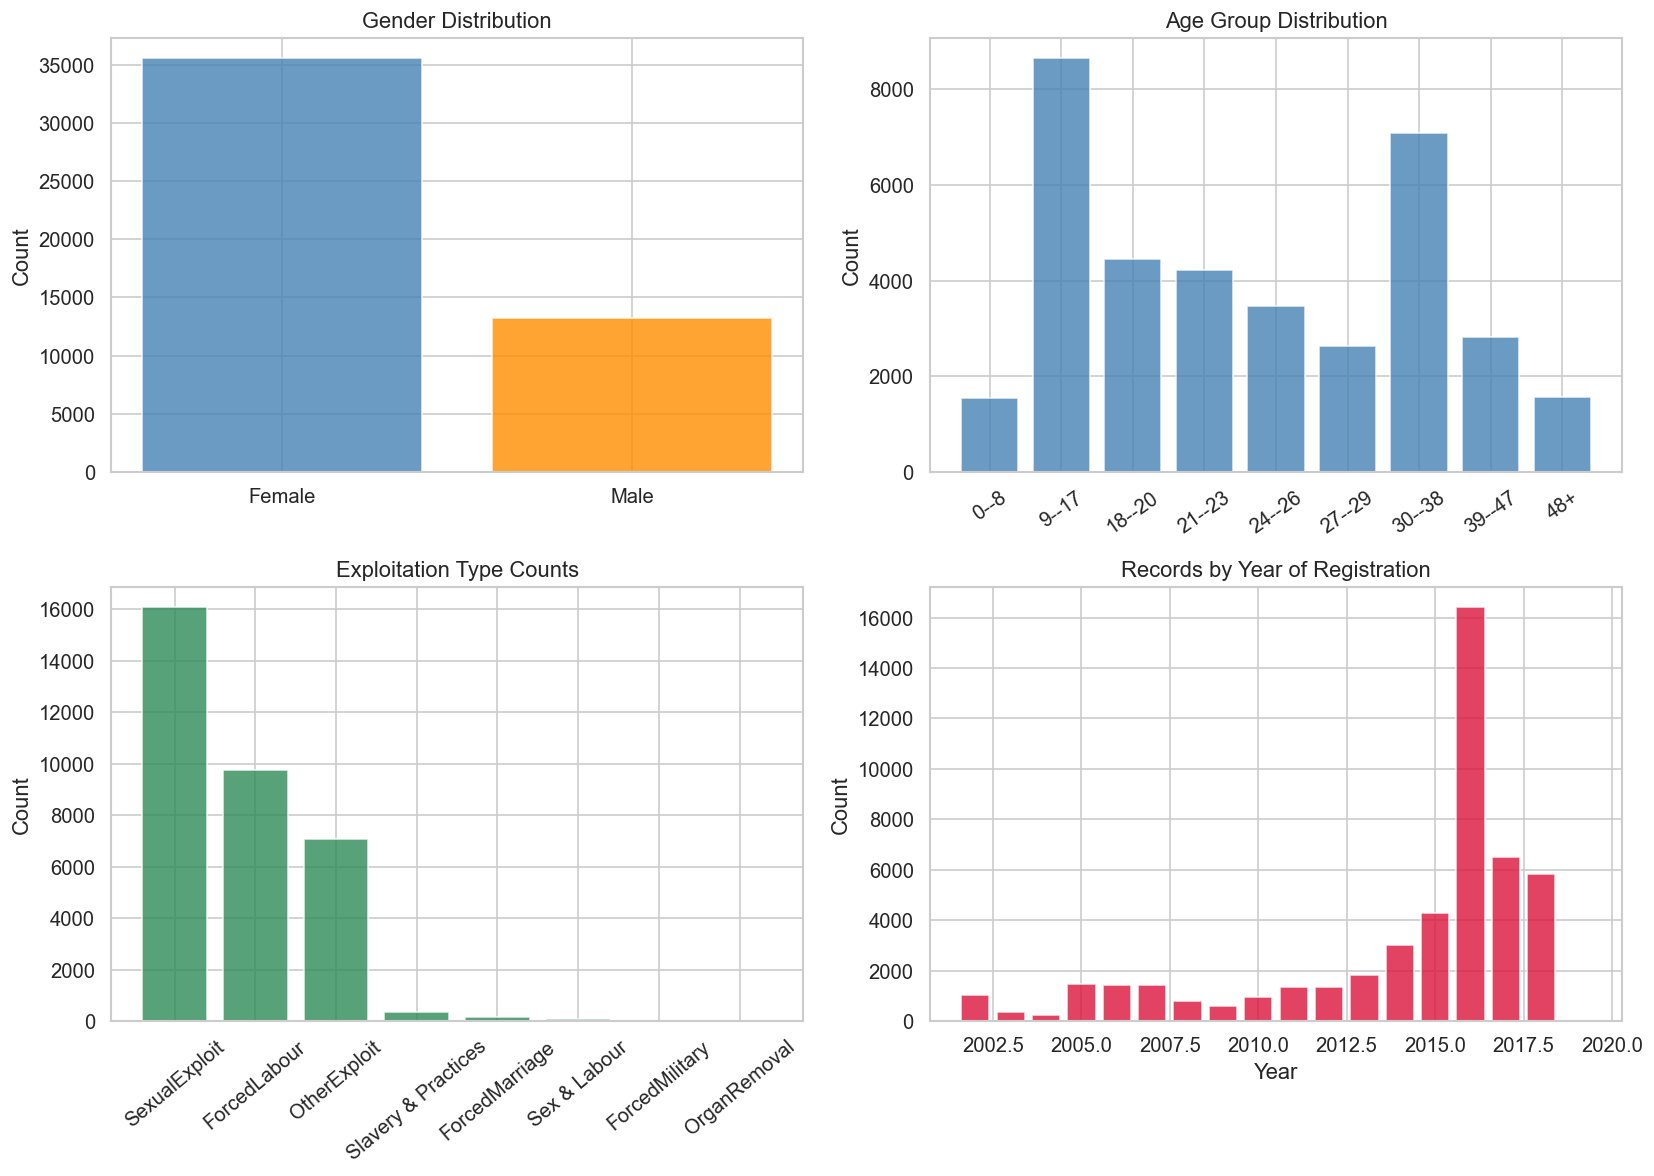

In [72]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gender
gender_counts = df_global['gender'].value_counts()
axes[0,0].bar(gender_counts.index, gender_counts.values, color=['steelblue','darkorange'], alpha=0.8)
axes[0,0].set_title('Gender Distribution')
axes[0,0].set_ylabel('Count')

# Age
age_order  = ['0--8','9--17','18--20','21--23','24--26','27--29','30--38','39--47','48+']
age_counts = df_global['ageBroad'].value_counts().reindex(age_order).dropna()
axes[0,1].bar(age_counts.index, age_counts.values, color='steelblue', alpha=0.8)
axes[0,1].set_title('Age Group Distribution')
axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(axis='x', rotation=35)

# Exploitation type
exploit_cols   = ['isForcedLabour','isSexualExploit','isOtherExploit','isSexAndLabour',
                   'isForcedMarriage','isForcedMilitary','isOrganRemoval','isSlaveryAndPractices']
exploit_counts = df_global[exploit_cols].sum().sort_values(ascending=False)
axes[1,0].bar(
    [c.replace('is','').replace('And',' & ') for c in exploit_counts.index],
    exploit_counts.values, color='seagreen', alpha=0.8
)
axes[1,0].set_title('Exploitation Type Counts')
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=40)

# Records by year
year_counts = df_global['yearOfRegistration'].value_counts().sort_index()
axes[1,1].bar(year_counts.index, year_counts.values, color='crimson', alpha=0.8)
axes[1,1].set_title('Records by Year of Registration')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()

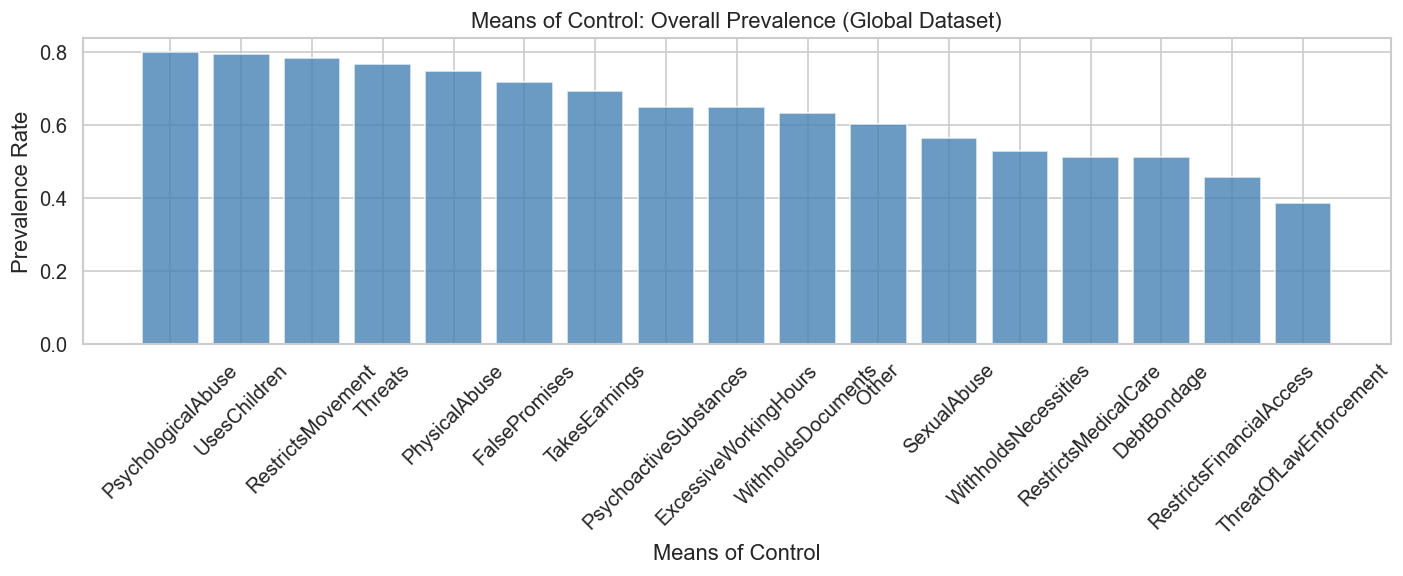

In [73]:
# Overall means of control prevalence
moc_cols   = [c for c in df_global.columns
               if c.startswith('meansOfControl')
               and c not in ('meansOfControlConcatenated','meansOfControlNotSpecified')]
moc_counts = df_global[moc_cols].sum()
moc_denom  = df_global[moc_cols].notna().sum()
moc_rate   = (moc_counts / moc_denom).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
labels = [c.replace('meansOfControl','') for c in moc_rate.index]
ax.bar(labels, moc_rate.values, color='steelblue', alpha=0.8)
ax.set_title('Means of Control: Overall Prevalence (Global Dataset)')
ax.set_xlabel('Means of Control')
ax.set_ylabel('Prevalence Rate')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Records by Datasource:
Datasource
Case Management    36289
Hotline            12512


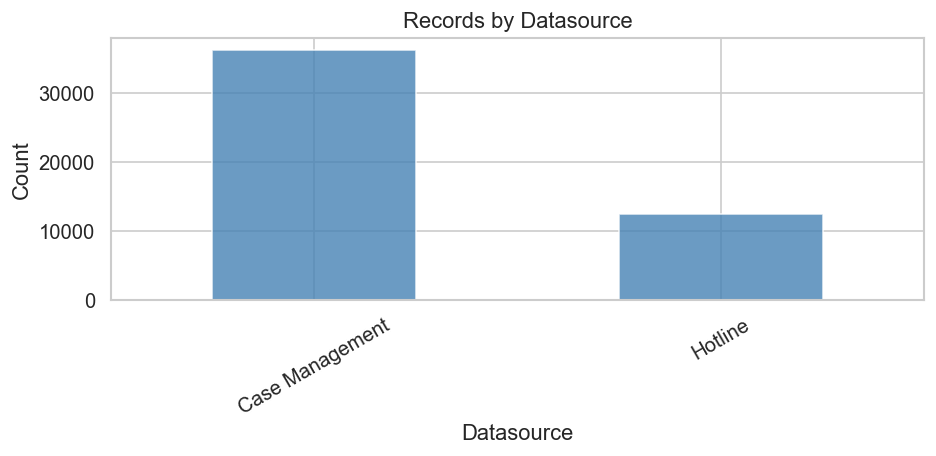

In [74]:
# Datasource composition
src_counts = df_global['Datasource'].value_counts()
print('Records by Datasource:')
print(src_counts.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
src_counts.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Records by Datasource')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

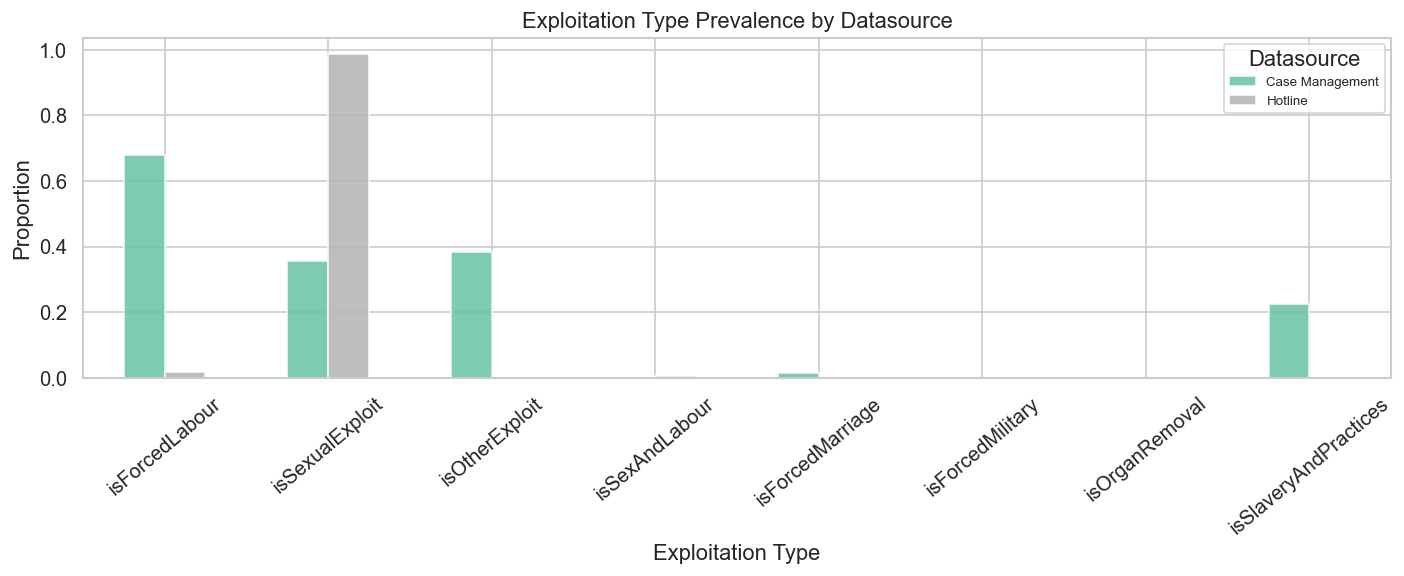

In [75]:
# Exploitation type prevalence by datasource
exploit_by_source = df_global.groupby('Datasource')[exploit_cols].mean()

fig, ax = plt.subplots(figsize=(12, 5))
exploit_by_source.T.plot(kind='bar', ax=ax, colormap='Set2', alpha=0.85)
ax.set_title('Exploitation Type Prevalence by Datasource')
ax.set_xlabel('Exploitation Type')
ax.set_ylabel('Proportion')
ax.tick_params(axis='x', rotation=40)
ax.legend(title='Datasource', fontsize=8)
plt.tight_layout()
plt.show()

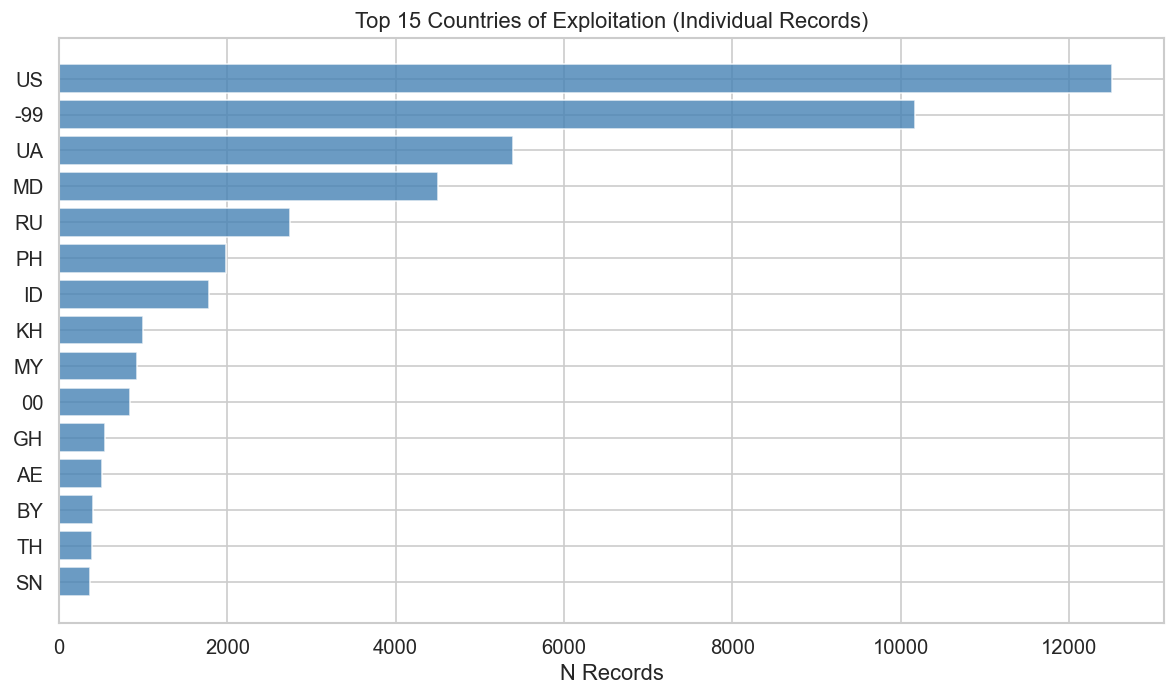

In [76]:
# Top 15 countries of exploitation (individual records)
top_countries = df_global['CountryOfExploitation'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_countries.index[::-1], top_countries.values[::-1], color='steelblue', alpha=0.8)
ax.set_title('Top 15 Countries of Exploitation (Individual Records)')
ax.set_xlabel('N Records')
plt.tight_layout()
plt.show()

**Explanation:**  
After replacing the -99 sentinel values with NaN, missingness is widespread and clearly not missing completely at random. The pattern correlates with both the datasource and the year of registration, which means we are dealing with structurally missing data that needs to be modeled rather than just imputed or ignored. IOM data dominates certain years and regions while Polaris dominates the US records, and each of these organizations screens and identifies victims differently. This datasource-driven selection effect is the central identification challenge for any model built on this data. Treating the datasource as a capture process indicator in the capture-recapture framework is probably the most principled way to handle it.

---
## 10. Cross-Dataset Synthesis

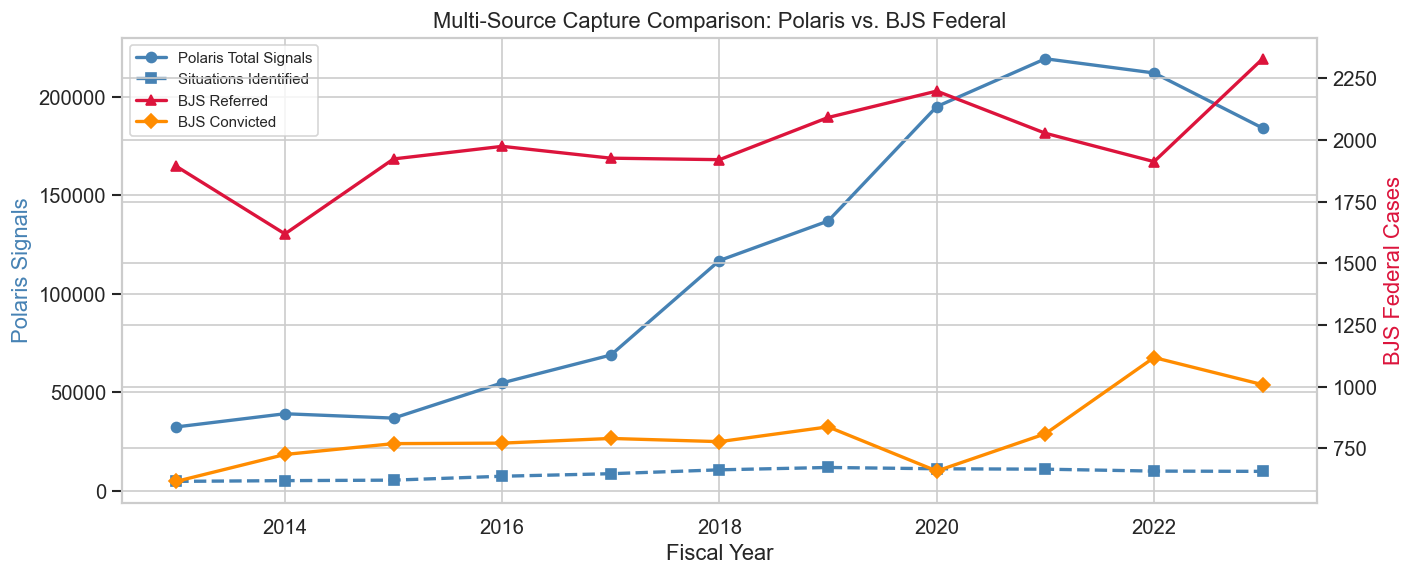

In [77]:
# Align Polaris signals and BJS prosecution on common fiscal years
merged = pd.merge(
    df01[['fiscal_year','total_signals','potential_situations_identified']],
    df08[['fiscal_year','suspects_referred_to_us_attorneys','defendants_convicted']],
    on='fiscal_year'
)

fig, ax = plt.subplots(figsize=(12, 5))
ax2 = ax.twinx()

ax.plot(merged['fiscal_year'], merged['total_signals'],
        marker='o', linewidth=2, color='steelblue', label='Polaris Total Signals')
ax.plot(merged['fiscal_year'], merged['potential_situations_identified'],
        marker='s', linewidth=2, color='steelblue', linestyle='--', label='Situations Identified')
ax2.plot(merged['fiscal_year'], merged['suspects_referred_to_us_attorneys'],
         marker='^', linewidth=2, color='crimson', label='BJS Referred')
ax2.plot(merged['fiscal_year'], merged['defendants_convicted'],
         marker='D', linewidth=2, color='darkorange', label='BJS Convicted')

ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Polaris Signals', color='steelblue')
ax2.set_ylabel('BJS Federal Cases', color='crimson')
ax.set_title('Multi-Source Capture Comparison: Polaris vs. BJS Federal')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=9)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

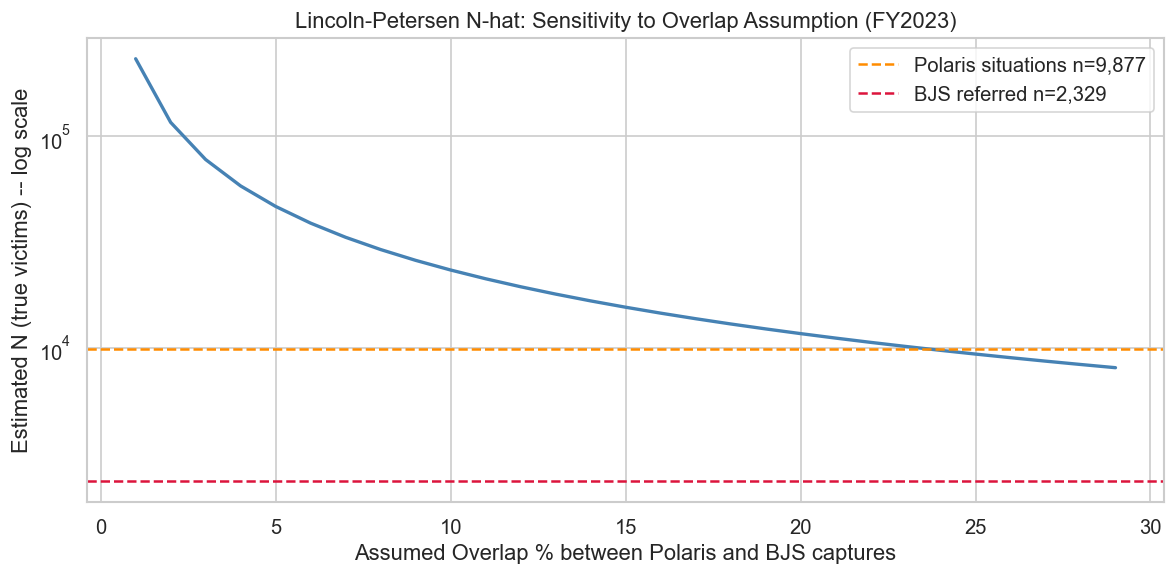

Polaris situations FY2023: 9,877
BJS referred FY2023: 2,329
At 5%  overlap -> N-hat = 46,580
At 10% overlap -> N-hat = 23,290


In [78]:
# Lincoln-Petersen naive estimate: sensitivity analysis over overlap assumptions
n1 = df01[df01['fiscal_year'] == 2023]['potential_situations_identified'].values[0]
n2 = df08[df08['fiscal_year'] == 2023]['suspects_referred_to_us_attorneys'].values[0]

overlap_range = np.arange(0.01, 0.30, 0.01)
n_hats = [(n1 * n2) / (n1 * p) for p in overlap_range]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(overlap_range * 100, n_hats, linewidth=2, color='steelblue')
ax.axhline(y=n1, color='darkorange', linestyle='--', label=f'Polaris situations n={n1:,}')
ax.axhline(y=n2, color='crimson',    linestyle='--', label=f'BJS referred n={n2:,}')
ax.set_title('Lincoln-Petersen N-hat: Sensitivity to Overlap Assumption (FY2023)')
ax.set_xlabel('Assumed Overlap % between Polaris and BJS captures')
ax.set_ylabel('Estimated N (true victims) -- log scale')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Polaris situations FY2023: {n1:,}')
print(f'BJS referred FY2023: {n2:,}')
print(f'At 5%  overlap -> N-hat = {int((n1*n2)/(n1*0.05)):,}')
print(f'At 10% overlap -> N-hat = {int((n1*n2)/(n1*0.10)):,}')

---
## 11. EDA Summary and Modeling Implications

| Dataset | Key Finding | Modeling Implication |
|---|---|---|
| 01 Polaris Signals | 6x growth then 29% decline; victim-signal ratio stays stable | BSTS decomposition: trend + shock (FOSTA-SESTA) + residual |
| 02 OVC Served | Sex TF grew YoY; labor flat; within-year Q4 dip | Capacity-constrained model; use as capture layer 2 |
| 03 CTDC by Year | Record count reflects datasource expansion, not crime trends; gender mix shifts | Year x datasource fixed effects needed |
| 04 Means of Control | Posterior mean stable for high-n cells; shrinks for low-n | Starting priors for Hierarchical Beta-Binomial |
| 05 Top 30 Countries | US dominates due to Polaris inclusion, not actual prevalence | Datasource covariate in hierarchical model |
| 06 Age x Gender | Sexual exploit peaks 18-26 female; male victims likely undercounted | Stratified priors; post-stratification for inference |
| 07 State Hotline | High inter-state heterogeneity in case-to-signal rate | Strong motivation for partial pooling across states |
| 08 BJS Federal | ~50% prosecution rate; high conviction rate once prosecuted | Third capture layer; capacity-constrained Poisson |
| Global Dataset | -99 missingness is MNAR and datasource-driven | Joint model of missingness; datasource as latent stratum |

The thread running through all of these findings is the same: every number in every dataset reflects how much trafficking was detected by a particular organization with a particular set of screening criteria, not how much trafficking actually occurred. Any model that takes these counts at face value without accounting for the detection funnel will produce estimates that are more about reporting capacity than about the underlying phenomenon.
